# PM25Vision | GoogLeNet (Inception-V3) | Split 40:60
**Dataset:** PM25Vision — AQI image classification (6 classes)
**Model:** GoogLeNet (Inception-V3) (ImageNet pretrained via timm)
**Split:** 40% of combined data for train / 60% for test (10% of train → val)
**Input size:** 224×224

In [1]:
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q",
                "timm","thop","scikit-learn","matplotlib","seaborn"], check=True)

import os, time, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import timm
from thop import profile as thop_profile
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


## 1 · Dataset Probe (inspect CSV structure)

In [2]:
# ── Quick dataset probe (runs once, safe to skip after first run) ────────────
import os, pandas as pd

TRAIN_CSV = "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv"
TEST_CSV  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/metadata.csv"
TRAIN_IMG = "/kaggle/input/datasets/deadcardassian/pm25vision/train/images"
TEST_IMG  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/images"

tr = pd.read_csv(TRAIN_CSV)
te = pd.read_csv(TEST_CSV)
print("Train CSV columns :", tr.columns.tolist())
print("Train CSV head    :\n", tr.head(3).to_string())
print("\nTest  CSV columns :", te.columns.tolist())
print("Test  CSV head    :\n", te.head(3).to_string())
print("\nTrain images sample:", os.listdir(TRAIN_IMG)[:5])
print("Test  images sample:", os.listdir(TEST_IMG)[:5])

Train CSV columns : ['image_id', 'station_id', 'captured_at', 'camera_angle', 'longitude', 'latitude', 'quality_score', 'downloaded_at', 'pm25', 'filename', 'quality', 'pm25_bin']
Train CSV head    :
            image_id  station_id captured_at  camera_angle   longitude   latitude  quality_score               downloaded_at  pm25              filename quality pm25_bin
0  1299925057505266       13051  2024-01-17           NaN  121.293349  25.027580            NaN  2025-09-12T08:00:56.871094  39.0  1299925057505266.jpg    good     0–50
1   924249681642820        3705  2017-12-30           NaN  139.235777  35.354056            NaN  2025-09-07T22:39:44.846055  19.0   924249681642820.jpg    good     0–50
2   498043544721455        3278  2020-01-02           NaN  145.714003 -40.989167            NaN  2025-09-07T18:25:10.505759   9.0   498043544721455.jpg    good     0–50

Test  CSV columns : ['image_id', 'station_id', 'captured_at', 'camera_angle', 'longitude', 'latitude', 'quality_score', 'd

## 2 · Load Dataset from Metadata CSVs

In [3]:
import os, pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

TRAIN_CSV = "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv"
TEST_CSV  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/metadata.csv"
TRAIN_IMG = "/kaggle/input/datasets/deadcardassian/pm25vision/train/images"
TEST_IMG  = "/kaggle/input/datasets/deadcardassian/pm25vision/test/images"

# ── Read metadata CSVs ────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# ── Detect filename & label columns automatically ─────────────────────────────
def detect_cols(df):
    # filename column: first column containing strings with image extensions
    fname_col, label_col = None, None
    for c in df.columns:
        s = df[c].astype(str)
        if s.str.contains(r"\.(jpg|jpeg|png|bmp|webp)", case=False, regex=True).any():
            fname_col = c; break
    if fname_col is None:
        fname_col = df.columns[0]          # fallback: first column

    # label column: column named bin/class/label/aqi or last int column
    for c in df.columns:
        if c.lower() in ("bin","class","label","aqi","category","pm25_bin","aqi_bin","level"):
            label_col = c; break
    if label_col is None:
        for c in reversed(df.columns):    # fallback: last numeric column
            if pd.api.types.is_integer_dtype(df[c]) or pd.api.types.is_float_dtype(df[c]):
                label_col = c; break
    if label_col is None:
        label_col = df.columns[-1]
    return fname_col, label_col

tr_fname, tr_label = detect_cols(train_df)
te_fname, te_label = detect_cols(test_df)
print(f"Train: filename={tr_fname!r}  label={tr_label!r}")
print(f"Test : filename={te_fname!r}  label={te_label!r}")

# ── Remap labels to 0-based int if needed ─────────────────────────────────────
all_labels = sorted(pd.concat([train_df[tr_label], test_df[te_label]]).unique())
label_map  = {orig: i for i, orig in enumerate(all_labels)}
train_df["_label"] = train_df[tr_label].map(label_map)
test_df["_label"]  = test_df[te_label].map(label_map)
NUM_CLASSES = len(all_labels)
print(f"Classes ({NUM_CLASSES}): {label_map}")

CLASS_NAMES = [str(k) for k in all_labels]

# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class PM25Dataset(Dataset):
    def __init__(self, df, img_dir, fname_col, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.fname_col = fname_col
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row   = self.df.iloc[i]
        fname = str(row[self.fname_col])
        # handle cases where filename already has a path prefix
        fname = os.path.basename(fname)
        path  = os.path.join(self.img_dir, fname)
        img   = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, int(row["_label"])

Train: filename='filename'  label='pm25_bin'
Test : filename='filename'  label='pm25_bin'
Classes (6): {'0–50': 0, '101–150': 1, '151–200': 2, '201–300': 3, '301–600': 4, '51–100': 5}


## 3 · Hyperparameters

In [4]:
# ════════════════════════════════════════════════════════════
#  Only this block differs across the 36 notebooks
# ════════════════════════════════════════════════════════════
MODEL_KEY    = "googlenet"
MODEL_NAME   = "GoogLeNet (Inception-V3)"
TIMM_NAME    = "inception_v3"
IMG_SIZE     = 224
TRAIN_FRAC   = 0.4   # fraction of FULL pool used for training
TEST_FRAC    = 0.6    # fraction of FULL pool used for testing
VAL_FRAC     = 0.10              # fraction of training portion used for validation
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 60
PATIENCE     = 10
# ════════════════════════════════════════════════════════════
print(f"Model : {MODEL_NAME}  |  Split : 40:60")

Model : GoogLeNet (Inception-V3)  |  Split : 40:60


## 4 · Transforms

In [5]:
mean, std = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

## 5 · Build Train / Val / Test Split

In [6]:
# Pool train_df + test_df, then re-split at the desired ratio
full_df = pd.concat([train_df, test_df], ignore_index=True)
all_idx  = list(range(len(full_df)))
all_lbls = full_df["_label"].tolist()

print(f"Full pool : {len(full_df)} images  |  {NUM_CLASSES} classes")

# Stratified split → train+val  vs  test
train_val_idx, test_idx = train_test_split(
    all_idx, test_size=TEST_FRAC, stratify=all_lbls, random_state=SEED)

# Stratified split → train  vs  val
tv_lbls = [full_df["_label"].iloc[i] for i in train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=VAL_FRAC, stratify=tv_lbls, random_state=SEED)

print(f"Split 40:60  |  Train={len(train_idx)}  Val={len(val_idx)}  Test={len(test_idx)}")

# ── Build per-subset DataFrames (preserve correct img_dir per row) ────────────
# original train_df rows come from TRAIN_IMG, test_df rows from TEST_IMG
n_train_orig = len(train_df)

def make_subset_df(indices):
    rows = []
    for i in indices:
        row = full_df.iloc[i].copy()
        img_dir = TRAIN_IMG if i < n_train_orig else TEST_IMG
        row["_img_dir"] = img_dir
        rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)

train_sub = make_subset_df(train_idx)
val_sub   = make_subset_df(val_idx)
test_sub  = make_subset_df(test_idx)

class PM25Subset(torch.utils.data.Dataset):
    def __init__(self, df, fname_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.fname_col = fname_col
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row   = self.df.iloc[i]
        fname = os.path.basename(str(row[self.fname_col]))
        path  = os.path.join(row["_img_dir"], fname)
        img   = __import__("PIL").Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, int(row["_label"])

# Use tr_fname as filename column (same across both CSVs)
fname_col = tr_fname
train_ds = PM25Subset(train_sub, fname_col, train_tf)
val_ds   = PM25Subset(val_sub,   fname_col, eval_tf)
test_ds  = PM25Subset(test_sub,  fname_col, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Loaders ready — Train:{len(train_loader)} Val:{len(val_loader)} Test:{len(test_loader)} batches")

Full pool : 11219 images  |  6 classes
Split 40:60  |  Train=4038  Val=449  Test=6732
Loaders ready — Train:127 Val:15 Test:211 batches


## 6 · Class Distribution

  Class  Train  Val  Test
   0–50    867   97  1446
101–150    868   96  1446
151–200    867   97  1446
201–300    394   44   659
301–600    174   19   289
 51–100    868   96  1446


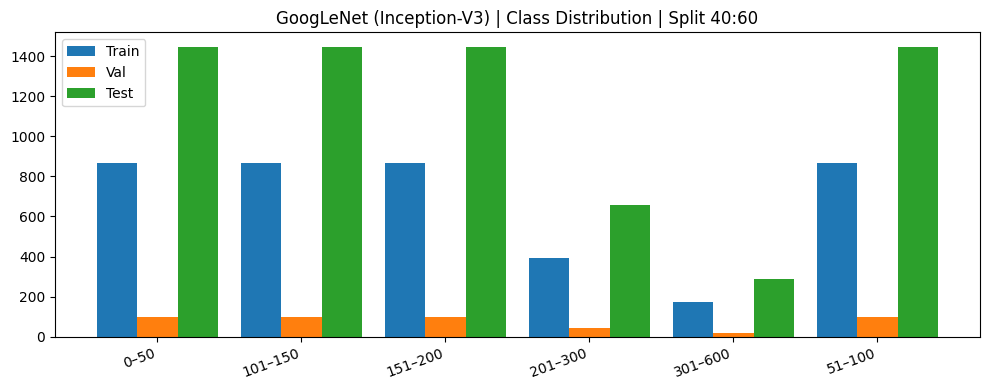

In [7]:
def count_labels(df):
    return [int((df["_label"]==i).sum()) for i in range(NUM_CLASSES)]

tr_cnt = count_labels(train_sub)
va_cnt = count_labels(val_sub)
te_cnt = count_labels(test_sub)
df_dist = pd.DataFrame({"Class":CLASS_NAMES,"Train":tr_cnt,"Val":va_cnt,"Test":te_cnt})
print(df_dist.to_string(index=False))

x = np.arange(NUM_CLASSES); w = 0.28
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(x-w, tr_cnt, w, label="Train")
ax.bar(x,   va_cnt, w, label="Val")
ax.bar(x+w, te_cnt, w, label="Test")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.set_title(f"GoogLeNet (Inception-V3) | Class Distribution | Split 40:60")
ax.legend(); plt.tight_layout(); plt.show()

## 7 · Build Model & Compute GFLOPs

In [8]:
model = timm.create_model(TIMM_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params — Total:{total_p/1e6:.2f}M | Trainable:{train_p/1e6:.2f}M")

dummy = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
macs, _ = thop_profile(model, inputs=(dummy,), verbose=False)
gflops  = macs / 1e9
print(f"GFLOPs @ {IMG_SIZE}×{IMG_SIZE} : {gflops:.3f}")

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

Params — Total:21.80M | Trainable:21.80M
GFLOPs @ 224×224 : 2.836


## 8 · Training

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

history = {k:[] for k in ["train_loss","train_acc","val_loss","val_acc"]}
best_val_loss, patience_cnt, best_state = float("inf"), 0, None
train_wall_start = time.time()

for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    tl, tc, tt = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs); loss = criterion(out, lbls)
        loss.backward(); optimizer.step()
        tl += loss.item()*imgs.size(0)
        tc += (out.argmax(1)==lbls).sum().item()
        tt += imgs.size(0)
    tl/=tt; ta=tc/tt

    model.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = model(imgs); loss = criterion(out, lbls)
            vl += loss.item()*imgs.size(0)
            vc += (out.argmax(1)==lbls).sum().item()
            vt += imgs.size(0)
    vl/=vt; va=vc/vt
    scheduler.step()

    for k,v in zip(["train_loss","train_acc","val_loss","val_acc"],[tl,ta,vl,va]):
        history[k].append(v)

    if vl < best_val_loss:
        best_val_loss=vl; patience_cnt=0
        best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
    else:
        patience_cnt+=1

    if epoch%5==0 or epoch==1:
        print(f"Ep {epoch:03d}/{MAX_EPOCHS} | TrL={tl:.4f} TrA={ta:.4f} | ValL={vl:.4f} ValA={va:.4f} | Pat={patience_cnt}/{PATIENCE}")

    if patience_cnt>=PATIENCE and epoch>=50:
        print(f"Early stop at epoch {epoch}"); break

train_wall_time = time.time()-train_wall_start
epochs_ran = len(history["train_loss"])
model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
print(f"\nTrain wall-clock : {train_wall_time:.1f}s ({train_wall_time/60:.2f} min) | Best weights restored.")

Ep 001/60 | TrL=1.7150 TrA=0.3160 | ValL=1.6840 ValA=0.3296 | Pat=0/10
Ep 005/60 | TrL=0.7666 TrA=0.7031 | ValL=1.5149 ValA=0.4811 | Pat=2/10
Ep 010/60 | TrL=0.2881 TrA=0.8960 | ValL=1.7647 ValA=0.5390 | Pat=7/10
Ep 015/60 | TrL=0.1666 TrA=0.9391 | ValL=1.8872 ValA=0.5657 | Pat=12/10
Ep 020/60 | TrL=0.0961 TrA=0.9671 | ValL=1.9954 ValA=0.5768 | Pat=17/10
Ep 025/60 | TrL=0.0867 TrA=0.9703 | ValL=2.1502 ValA=0.5724 | Pat=22/10
Ep 030/60 | TrL=0.0344 TrA=0.9874 | ValL=2.3470 ValA=0.5702 | Pat=27/10
Ep 035/60 | TrL=0.0395 TrA=0.9876 | ValL=2.3102 ValA=0.5568 | Pat=32/10
Ep 040/60 | TrL=0.0195 TrA=0.9938 | ValL=2.3869 ValA=0.5880 | Pat=37/10
Ep 045/60 | TrL=0.0172 TrA=0.9931 | ValL=2.4538 ValA=0.5724 | Pat=42/10
Ep 050/60 | TrL=0.0142 TrA=0.9958 | ValL=2.6157 ValA=0.5724 | Pat=47/10
Early stop at epoch 50

Train wall-clock : 2537.0s (42.28 min) | Best weights restored.


## 9 · Learning Curves

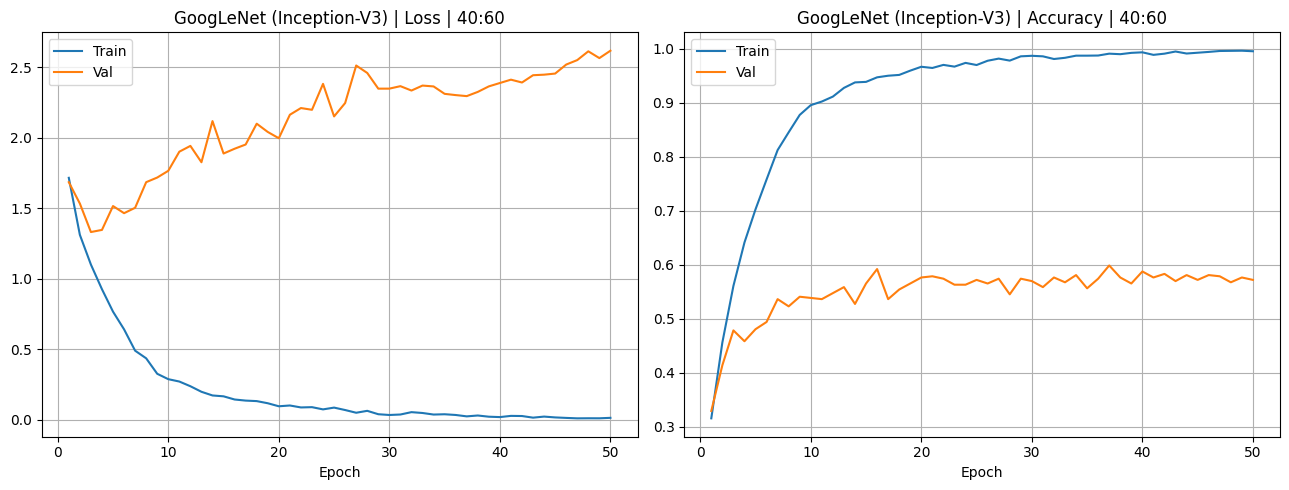

In [10]:
ep = range(1, epochs_ran+1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
ax1.plot(ep,history["train_loss"],label="Train"); ax1.plot(ep,history["val_loss"],label="Val")
ax1.set_title("GoogLeNet (Inception-V3) | Loss | 40:60"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)
ax2.plot(ep,history["train_acc"],label="Train"); ax2.plot(ep,history["val_acc"],label="Val")
ax2.set_title("GoogLeNet (Inception-V3) | Accuracy | 40:60"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig("lc_googlenet_40_60.png", dpi=150); plt.show()

## 10 · Test Evaluation

In [11]:
model.eval()
all_preds, all_probs, all_lbls = [], [], []
test_wall_start = time.time()
with torch.no_grad():
    for imgs, lbls in test_loader:
        logits = model(imgs.to(DEVICE))
        probs  = torch.softmax(logits,1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_lbls.extend(lbls.numpy())
test_wall_time = time.time()-test_wall_start

all_preds=np.array(all_preds); all_probs=np.array(all_probs); all_lbls=np.array(all_lbls)

acc      = accuracy_score(all_lbls,all_preds)
prec_mac = precision_score(all_lbls,all_preds,average="macro",zero_division=0)
rec_mac  = recall_score(all_lbls,all_preds,average="macro",zero_division=0)
f1_mac   = f1_score(all_lbls,all_preds,average="macro",zero_division=0)
try:    roc_auc = roc_auc_score(all_lbls,all_probs,multi_class="ovr",average="macro")
except: roc_auc = float("nan")

cm = confusion_matrix(all_lbls,all_preds)
per_class_acc = cm.diagonal()/cm.sum(axis=1)

print("="*60)
print(f"  Accuracy        : {acc:.4f}")
print(f"  Macro Precision : {prec_mac:.4f}")
print(f"  Macro Recall    : {rec_mac:.4f}")
print(f"  Macro F1        : {f1_mac:.4f}")
print(f"  Macro ROC-AUC   : {roc_auc:.4f}")
print(f"  Train Time (s)  : {train_wall_time:.1f}")
print(f"  Test  Time (s)  : {test_wall_time:.2f}")
print(f"  GFLOPs          : {gflops:.3f}")
print("="*60)
for name,pa in zip(CLASS_NAMES,per_class_acc):
    print(f"  Per-class Acc [{name}]: {pa:.4f}")
print(); print(classification_report(all_lbls,all_preds,target_names=CLASS_NAMES))

  Accuracy        : 0.4687
  Macro Precision : 0.5138
  Macro Recall    : 0.4886
  Macro F1        : 0.4929
  Macro ROC-AUC   : 0.8135
  Train Time (s)  : 2537.0
  Test  Time (s)  : 81.17
  GFLOPs          : 2.836
  Per-class Acc [0–50]: 0.6694
  Per-class Acc [101–150]: 0.3693
  Per-class Acc [151–200]: 0.4827
  Per-class Acc [201–300]: 0.5432
  Per-class Acc [301–600]: 0.5675
  Per-class Acc [51–100]: 0.2994

              precision    recall  f1-score   support

        0–50       0.43      0.67      0.53      1446
     101–150       0.43      0.37      0.40      1446
     151–200       0.61      0.48      0.54      1446
     201–300       0.74      0.54      0.63       659
     301–600       0.55      0.57      0.56       289
      51–100       0.33      0.30      0.31      1446

    accuracy                           0.47      6732
   macro avg       0.51      0.49      0.49      6732
weighted avg       0.48      0.47      0.47      6732



## 11 · Confusion Matrix & Failure Modes

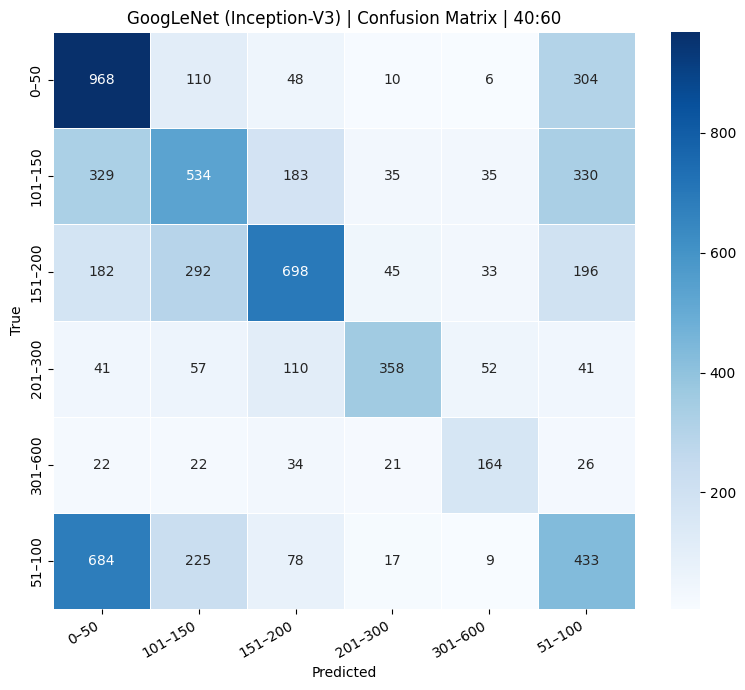

Top confused pairs:
  True=51–100 → Pred=0–50 : 684
  True=101–150 → Pred=51–100 : 330
  True=101–150 → Pred=0–50 : 329
  True=0–50 → Pred=51–100 : 304
  True=151–200 → Pred=101–150 : 292
  True=51–100 → Pred=101–150 : 225
  True=151–200 → Pred=51–100 : 196
  True=101–150 → Pred=151–200 : 183


In [12]:
fig,ax = plt.subplots(figsize=(8,7))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax,linewidths=0.5)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"GoogLeNet (Inception-V3) | Confusion Matrix | 40:60")
plt.xticks(rotation=30,ha="right"); plt.tight_layout()
plt.savefig("cm_googlenet_40_60.png",dpi=150); plt.show()

print("Top confused pairs:")
od=[(cm[i,j],CLASS_NAMES[i],CLASS_NAMES[j])
    for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i!=j and cm[i,j]>0]
for cnt,t,p in sorted(od,reverse=True)[:8]:
    print(f"  True={t} → Pred={p} : {cnt}")

## 12 · ROC Curves

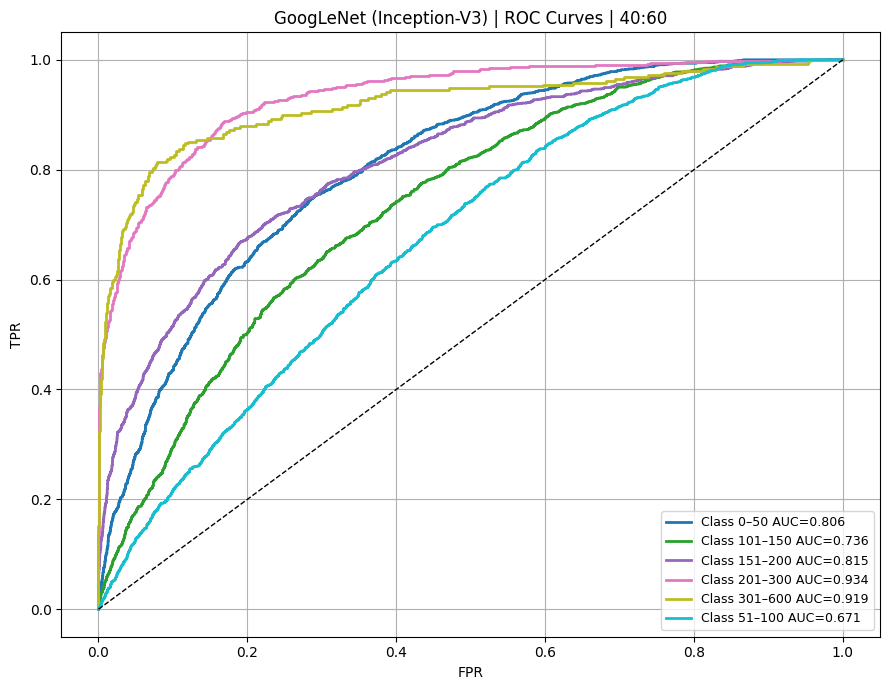

In [13]:
lbls_bin = label_binarize(all_lbls,classes=list(range(NUM_CLASSES)))
fig,ax   = plt.subplots(figsize=(9,7))
colors   = plt.cm.tab10(np.linspace(0,1,NUM_CLASSES))
for i in range(NUM_CLASSES):
    try:
        fpr,tpr,_ = roc_curve(lbls_bin[:,i],all_probs[:,i])
        auc_i = roc_auc_score(lbls_bin[:,i],all_probs[:,i])
        ax.plot(fpr,tpr,color=colors[i],lw=2,label=f"Class {CLASS_NAMES[i]} AUC={auc_i:.3f}")
    except: pass
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"GoogLeNet (Inception-V3) | ROC Curves | 40:60")
ax.legend(loc="lower right",fontsize=9); ax.grid(True); plt.tight_layout()
plt.savefig("roc_googlenet_40_60.png",dpi=150); plt.show()

## 13 · Save Summary CSV

In [14]:
summary = {
    "Model":MODEL_NAME, "Split":"40:60",
    "Input Size":f"{IMG_SIZE}x{IMG_SIZE}", "GFLOPs":round(gflops,3),
    "Train Samples":len(train_sub), "Val Samples":len(val_sub),
    "Test Samples":len(test_sub),   "Epochs Run":epochs_ran,
    "Accuracy":round(acc,4),
    "Macro Precision":round(prec_mac,4),
    "Macro Recall":round(rec_mac,4),
    "Macro F1":round(f1_mac,4),
    "Macro ROC-AUC":round(float(roc_auc),4),
    "Train Time (s)":round(train_wall_time,1),
    "Test Time (s)":round(test_wall_time,2),
}
for k,v in summary.items(): print(f"  {k:22s}: {v}")
fname = f"summary_googlenet_split40_60.csv"
pd.DataFrame([summary]).to_csv(fname,index=False)
print(f"\nSaved: {fname}")

  Model                 : GoogLeNet (Inception-V3)
  Split                 : 40:60
  Input Size            : 224x224
  GFLOPs                : 2.836
  Train Samples         : 4038
  Val Samples           : 449
  Test Samples          : 6732
  Epochs Run            : 50
  Accuracy              : 0.4687
  Macro Precision       : 0.5138
  Macro Recall          : 0.4886
  Macro F1              : 0.4929
  Macro ROC-AUC         : 0.8135
  Train Time (s)        : 2537.0
  Test Time (s)         : 81.17

Saved: summary_googlenet_split40_60.csv
